In [3]:
import matplotlib.pyplot as plt  
import numpy as np  

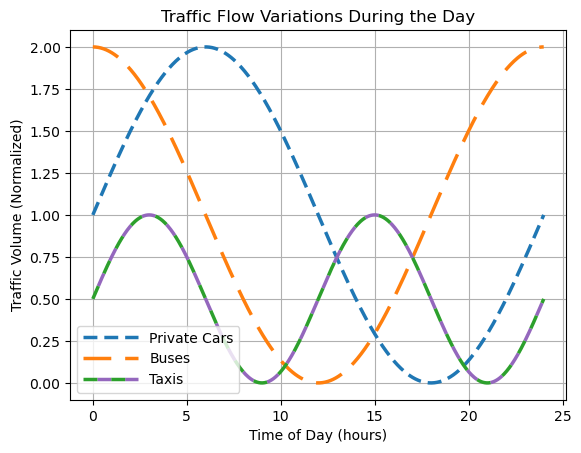

In [3]:
# 模拟一天中的时间（小时）  
x = np.linspace(0, 24, 500)  
  
# 假设的三种交通流量数据（为了简化，这里使用正弦波和余弦波稍作变形来模拟）  
y_cars = np.sin(x * np.pi / 12) + 1  # 私家车流量，假设高峰在上午和傍晚  
y_buses = np.cos(x * np.pi / 12) + 1  # 公交车流量，假设高峰在早上和晚上但较私家车平缓  
y_taxis = 0.5 * np.sin(x * np.pi / 6) + 0.5  # 出租车流量，假设高峰时段更长但幅度较小  
  
plt.rc('lines', linewidth=2.5)  
fig, ax = plt.subplots()  
  
# 私家车流量，高峰时段用短划线表示  
line1, = ax.plot(x, y_cars, label='Private Cars', dashes=[4, 2])  
  
# 公交车流量，使用更长的虚线表示，因为变化相对平缓  
line2, = ax.plot(x, y_buses, label='Buses', dashes=[8, 4])  
  
# 出租车流量，使用交替颜色的虚线表示，以突出其不同于其他两种交通的特点  
line3, = ax.plot(x, y_taxis, label='Taxis', dashes=[4, 4], gapcolor='tab:purple')  
  
# 设置图例和标签  
ax.legend(handlelength=4)  
ax.set_xlabel('Time of Day (hours)')  
ax.set_ylabel('Traffic Volume (Normalized)')  
ax.set_title('Traffic Flow Variations During the Day')  
  
# 为了更好地展示数据，我们可以添加网格线  
ax.grid(True)  
  
plt.show()

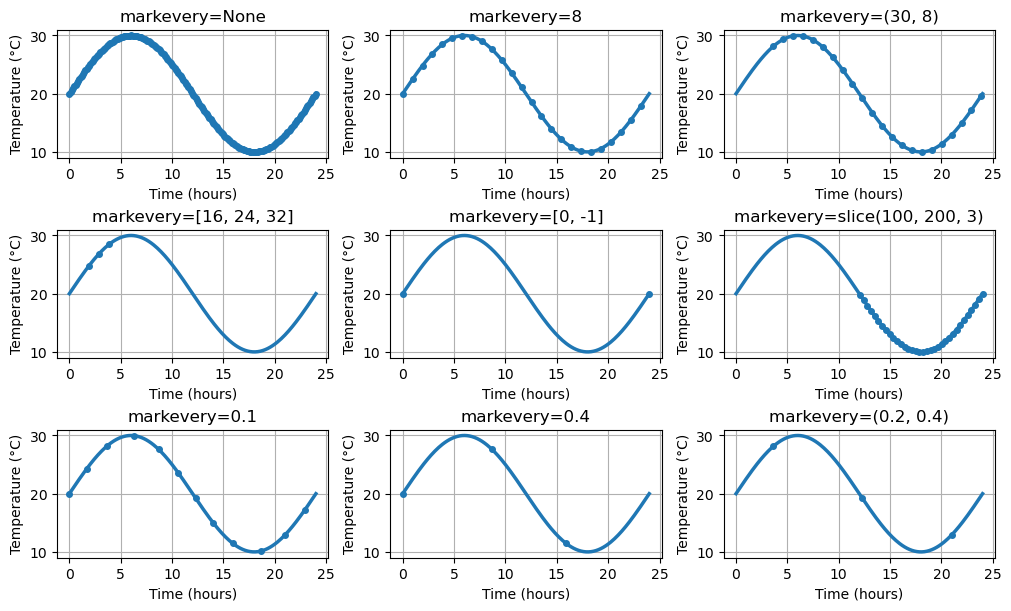

In [13]:
# define a list of markevery cases to plot  
cases = [  
    None,  
    8,  
    (30, 8),  
    [16, 24, 32],  
    [0, -1],  
    slice(100, 200, 3),  
    0.1,  
    0.4,  
    (0.2, 0.4)  
]  
  
# data points: time (in hours) and temperature (in Celsius)  
t = np.linspace(0, 24, 200)  # 24 hours  
T = 20 + 10 * np.sin(np.pi * t / 12)  # Temperature varying sinusoidally with a 12-hour period  
  
fig, axs = plt.subplots(3, 3, figsize=(10, 6), layout='constrained')  
for ax, markevery in zip(axs.flat, cases):  
    ax.set_title(f'markevery={markevery}')  
    ax.plot(t, T, 'o-', ms=4, markevery=markevery)  
    ax.set_xlabel('Time (hours)')  
    ax.set_ylabel('Temperature (°C)')  
    ax.grid(True)  
  
# plt.tight_layout()  
plt.show()

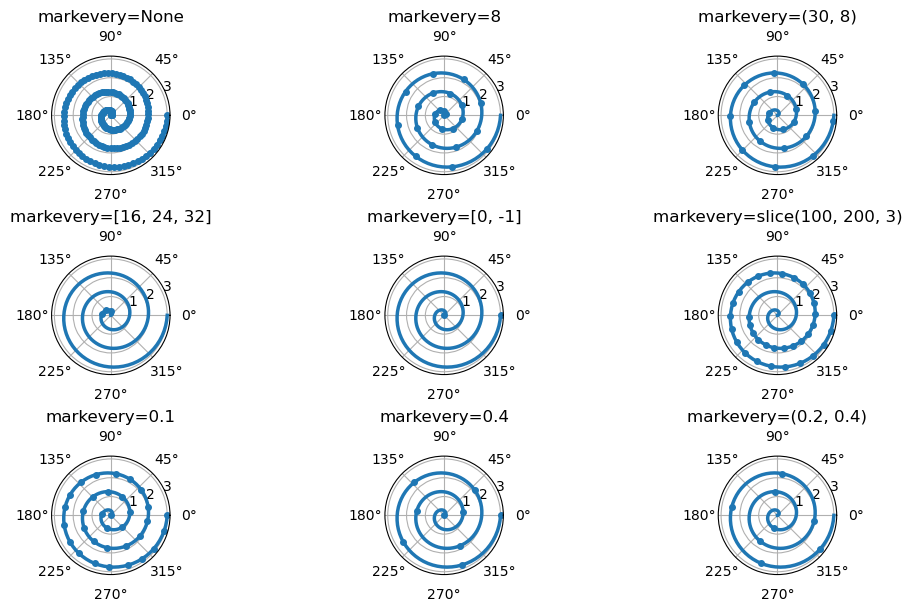

In [15]:
r = np.linspace(0, 3.0, 200)
theta = 2 * np.pi * r

fig, axs = plt.subplots(3, 3, figsize=(10, 6), layout='constrained',
                        subplot_kw={'projection': 'polar'})
for ax, markevery in zip(axs.flat, cases):
    ax.set_title(f'markevery={markevery}')
    ax.plot(theta, r, 'o', ls='-', ms=4, markevery=markevery)

plt.show()

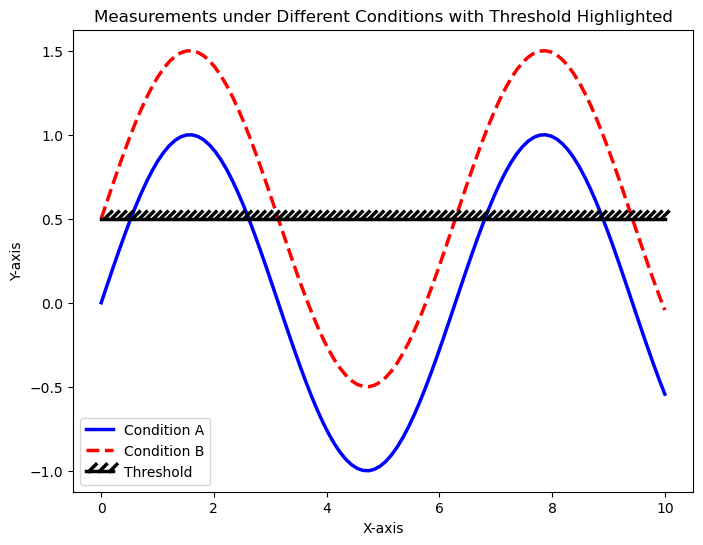

In [7]:
from matplotlib import patheffects  
  
# 假设有两个数据集，分别代表不同条件下的测量结果  
# 数据集1（条件A）  
x1 = np.linspace(0, 10, 100)  
y1 = np.sin(x1)  
  
# 数据集2（条件B），为了演示，我们将其平移并稍作修改  
x2 = np.linspace(0, 10, 100)  
y2 = np.sin(x2) + 0.5  
  
# 设定一个阈值或分类边界（这里简单地使用y=0.5作为示例）  
threshold_x = np.linspace(0, 10, 10)  
threshold_y = np.full_like(threshold_x, 0.5)  
  
# 创建图形和坐标轴  
fig, ax = plt.subplots(figsize=(8, 6))  
  
# 绘制两个数据集  
ax.plot(x1, y1, label='Condition A', linestyle='-', color='blue')  
ax.plot(x2, y2, label='Condition B', linestyle='--', color='red')  
  
# 绘制分类边界，并使用ticked stroke路径效果来突出显示  
ax.plot(threshold_x, threshold_y, label='Threshold', color='black',  
        path_effects=[patheffects.withTickedStroke(spacing=5, angle=45, offset=(0, 0))])  
  
# 添加图例  
ax.legend()  
  
# 设置坐标轴标签和标题  
ax.set_xlabel('X-axis')  
ax.set_ylabel('Y-axis')  
ax.set_title('Measurements under Different Conditions with Threshold Highlighted')  
  
# 显示图形  
plt.show()

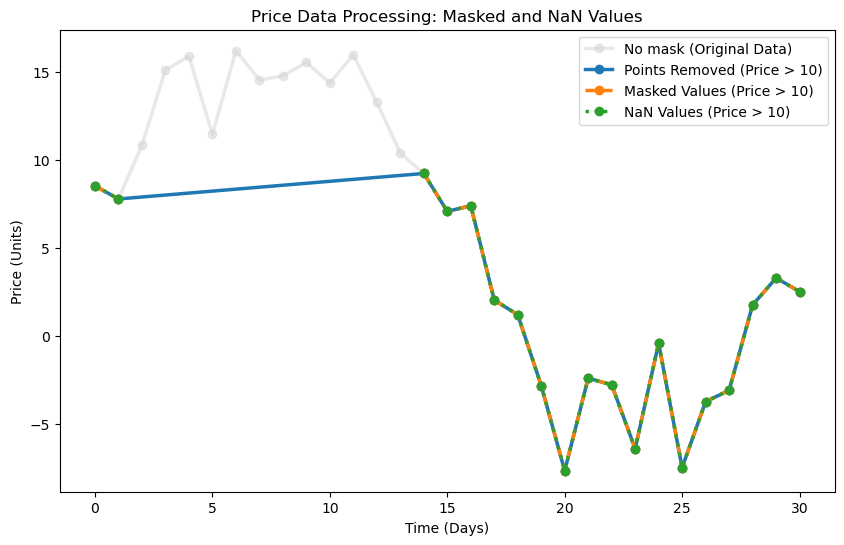

In [29]:
# 模拟时间数据（以天为单位），从0到30天  
x = np.linspace(0, 30, 31)  
  
# 模拟商品价格数据，使用正弦波加随机噪声来模拟价格波动  
np.random.seed(0)  # 设置随机种子以确保结果可重复  
y = np.sin(x / 5) * 10 + 5 + np.random.normal(0, 2, 31)  
  
# 1) 去除价格高于某个阈值（例如，10单位）的点  
x2 = x[y <= 10]  
y2 = y[y <= 10]  
  
# 2) 掩蔽价格高于阈值的点  
y3 = np.ma.masked_where(y > 10, y)  
  
# 3) 将价格高于阈值的点设置为NaN  
y4 = y.copy()  
y4[y > 10] = np.nan  
  
# 绘制图形  
plt.figure(figsize=(10, 6))  
  
# 绘制未处理的数据  
plt.plot(x, y, 'o-', color='lightgrey', alpha=0.5, label='No mask (Original Data)')  
  
# 绘制去除高价格点的数据  
plt.plot(x2, y2, 'o-', label='Points Removed (Price > 10)')  
  
# 绘制掩蔽高价格点的数据  
plt.plot(x, y3, 'o', label='Masked Values (Price > 10)', linestyle='--')  
  
# 绘制高价格点设置为NaN的数据  
plt.plot(x, y4, 'o', label='NaN Values (Price > 10)', linestyle=':')  
  
# 添加图例和标题  
plt.legend()  
plt.title('Price Data Processing: Masked and NaN Values')  
plt.xlabel('Time (Days)')  
plt.ylabel('Price (Units)')  
  
# 显示图形  
plt.show()

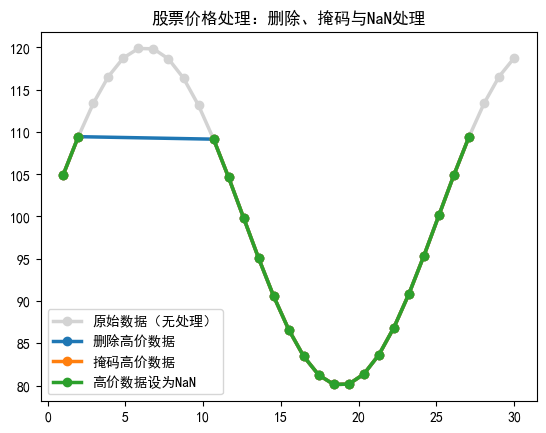

In [33]:
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为黑体  
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号
# 模拟股票市场价格数据
days = np.linspace(1, 30, 31)  # 30天
prices = 100 + 20 * np.sin(days / 4)  # 生成一些波动的价格

# 1) 删除价格高于110的点
days_removed = days[prices <= 110]
prices_removed = prices[prices <= 110]

# 2) 屏蔽价格高于110的点
prices_masked = np.ma.masked_where(prices > 110, prices)

# 3) 将价格高于110的点设为NaN
prices_nan = prices.copy()
prices_nan[prices > 110] = np.nan

# 绘制图表
plt.plot(days, prices, 'o-', color='lightgrey', label='原始数据（无处理）')
plt.plot(days_removed, prices_removed, 'o-', label='删除高价数据')
plt.plot(days, prices_masked, 'o-', label='掩码高价数据')
plt.plot(days, prices_nan, 'o-', label='高价数据设为NaN')

# 设置图例和标题
plt.legend()
plt.title('股票价格处理：删除、掩码与NaN处理')

# 显示图表
plt.show()


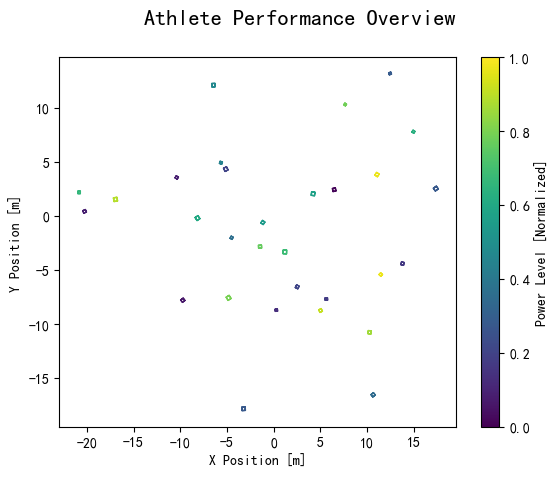

In [35]:
from matplotlib.colors import Normalize
from matplotlib.markers import MarkerStyle
from matplotlib.text import TextPath
from matplotlib.transforms import Affine2D

# 使用新的符号表示运动员的情绪
PERFORMANCE_SYMBOLS = [
    TextPath((0, 0), "😔"),  # 低分情绪
    TextPath((0, 0), "😐"),  # 中等分数情绪
    TextPath((0, 0), "😄"),  # 高分情绪
]

# 模拟运动员的比赛表现数据
N = 30
np.random.seed(24)
scores = np.random.uniform(50, 100, size=N)  # 运动员得分
throw_angles = np.random.normal(0, 90, N)  # 投掷角度
power_levels = np.random.uniform(size=N)  # 力量
emotions = np.random.randint(0, 3, size=N)  # 运动员情绪
positions = np.random.normal(size=(N, 2)) * 10  # 运动员位置
data = zip(scores, throw_angles, power_levels, emotions, positions)

# 使用不同的颜色映射展示力量的大小
cmap = plt.colormaps["viridis"]
fig, ax = plt.subplots()
fig.suptitle("Athlete Performance Overview", size=16)

# 循环遍历数据，绘制运动员的表现
for score, angle, power, emotion, pos in data:
    t = Affine2D().scale(score / 100).rotate_deg(angle)  # 根据分数和投掷角度缩放和旋转
    marker = MarkerStyle(PERFORMANCE_SYMBOLS[emotion], transform=t)  # 设置情绪符号
    ax.plot(pos[0], pos[1], marker=marker, color=cmap(power))  # 根据力量大小设置颜色

# 添加颜色条，表示力量的强弱
fig.colorbar(plt.cm.ScalarMappable(norm=Normalize(0, 1), cmap=cmap),
             ax=ax, label="Power Level [Normalized]")

# 设置轴标签
ax.set_xlabel("X Position [m]")
ax.set_ylabel("Y Position [m]")

plt.show()


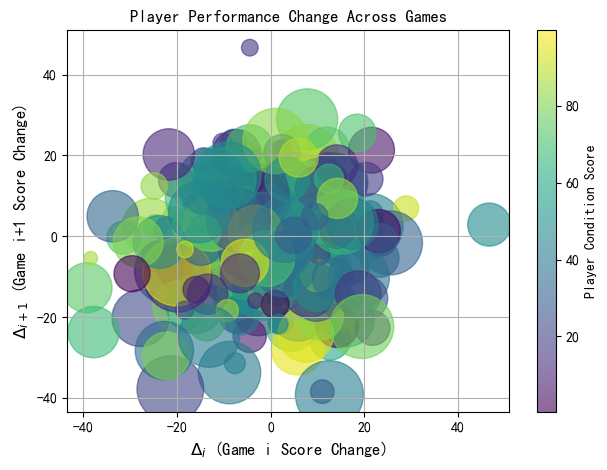

In [39]:
# 模拟球员在两场比赛之间的得分变化数据
np.random.seed(10)
player_count = 250
game_scores = np.random.normal(80, 10, size=(player_count, 2))  # 两场比赛的得分
score_diff = np.diff(game_scores, axis=1).flatten()  # 计算得分变化

# 模拟参与度（可以理解为上场时间或出手次数），以点大小表示
participation = np.random.randint(10, 50, size=player_count)**2

# 模拟球员的状态分数，作为颜色映射的依据
player_state = np.random.uniform(0, 100, size=player_count)

# 创建图表
fig, ax = plt.subplots()
scatter = ax.scatter(score_diff[:-1], score_diff[1:], c=player_state[:-1], s=participation[:-1], alpha=0.6)

# 设置坐标轴标签和标题
ax.set_xlabel(r'$\Delta_i$ (Game i Score Change)', fontsize=12)
ax.set_ylabel(r'$\Delta_{i+1}$ (Game i+1 Score Change)', fontsize=12)
ax.set_title('Player Performance Change Across Games')

# 添加颜色条，展示球员的状态分数
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Player Condition Score')

# 网格设置
ax.grid(True)
fig.tight_layout()

plt.show()


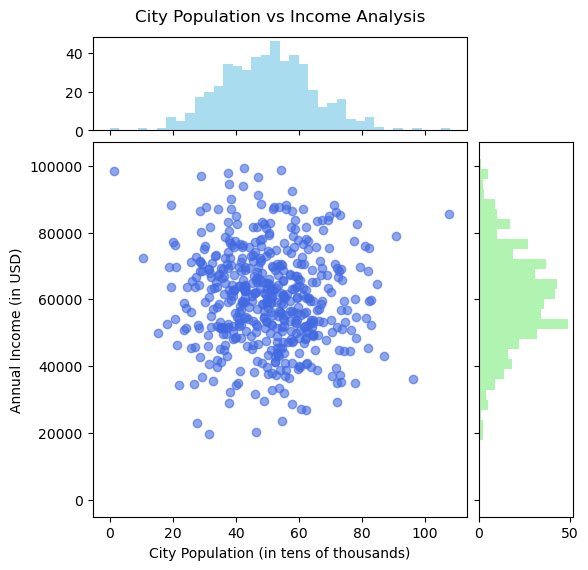

In [25]:
# 设置随机种子以保证可复现性
np.random.seed(42)

# 调整数据量为500个城市，减少绘图开销
population = np.random.normal(50, 15, 500)  # 城市人口（万）
income = np.random.normal(60000, 15000, 500)  # 城市收入（美元）

# 定义绘制散点图和直方图的函数
def scatter_hist(population, income, ax, ax_histx, ax_histy):
    # 关闭直方图坐标轴的刻度标签
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    # 绘制人口 vs 收入的散点图
    ax.scatter(population, income, alpha=0.6, color='royalblue')

    # 手动设置坐标轴的限度和直方图的范围
    binwidth = 3  # 调小 binwidth，提升效率
    pop_max = np.max(population)
    inc_max = np.max(income)

    # 计算直方图的bins
    pop_bins = np.arange(0, pop_max + binwidth, binwidth)
    inc_bins = np.arange(0, inc_max + binwidth * 1000, binwidth * 1000)

    # 绘制人口和收入的边缘直方图
    ax_histx.hist(population, bins=pop_bins, color='skyblue', alpha=0.7)
    ax_histy.hist(income, bins=inc_bins, orientation='horizontal', color='lightgreen', alpha=0.7)

# 创建图表和布局
fig = plt.figure(figsize=(6, 6))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

# 绘制散点图和边缘直方图
scatter_hist(population, income, ax, ax_histx, ax_histy)

# 添加标题和轴标签
ax.set_title("City Population vs Income Analysis", y=1.3)
ax.set_xlabel("City Population (in tens of thousands)")
ax.set_ylabel("Annual Income (in USD)")
# 调整布局，确保标题不会被挡住
# plt.tight_layout(rect=[0, 0, 1, 0.95])  # rect参数调整为标题留出空间
plt.show()


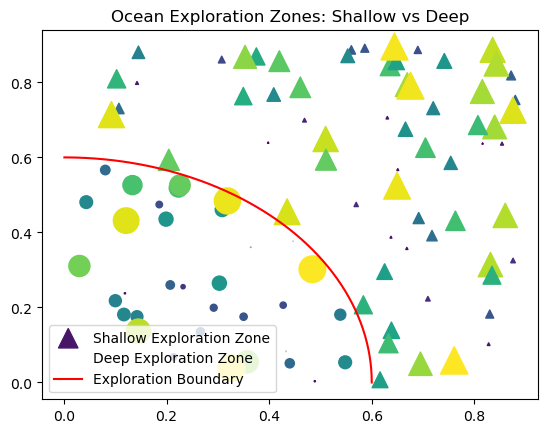

In [27]:
# 固定随机种子以保证结果可重复
np.random.seed(19680801)

# 模拟100艘潜水艇在海洋中的位置
N = 100
exploration_boundary = 0.6  # 设置一个探索边界
x = 0.9 * np.random.rand(N)  # 潜水艇的x坐标
y = 0.9 * np.random.rand(N)  # 潜水艇的y坐标
depth = (20 * np.random.rand(N))**2  # 使用面积来表示潜水深度
color_depth = np.sqrt(depth)  # 根据深度为潜水艇着色

# 计算潜水艇的距离半径，用于分配到不同区域
distance = np.sqrt(x ** 2 + y ** 2)
shallow_area = np.ma.masked_where(distance < exploration_boundary, depth)
deep_area = np.ma.masked_where(distance >= exploration_boundary, depth)

# 绘制潜水艇的探索范围：深潜区用圆形，浅潜区用三角形
plt.scatter(x, y, s=shallow_area, marker='^', c=color_depth, label='Shallow Exploration Zone')
plt.scatter(x, y, s=deep_area, marker='o', c=color_depth, label='Deep Exploration Zone')

# 绘制探索边界
theta = np.arange(0, np.pi / 2, 0.01)  # 使用角度范围来描绘边界
plt.plot(exploration_boundary * np.cos(theta), exploration_boundary * np.sin(theta), label='Exploration Boundary', color='red')

# 添加图例和标题
plt.legend()
plt.title('Ocean Exploration Zones: Shallow vs Deep')

# 显示图像
plt.show()
